In [1]:
import pandas as pd
import numpy as np
import os
import glob 
import matplotlib.pyplot as plt

# Plot 1:
** The results of Run 1/2 were taken without the float potential turned on 

In [2]:
# Reads in the MPA file and returns the realtime and totalsum values
def read_mpa_file(filepath):
    realtime = None
    totalsum = None
    roisum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum

# Gets the HV value from the filename
def get_hv(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return int(name_only)

def get_run(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1

data_folder = "HVControl"
rows = []

for filepath in glob.glob(os.path.join(data_folder, "HV*.mpa")):
    filename = os.path.basename(filepath)

    hv = get_hv(filename)
    run = get_run(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime

    rows.append({
        "hv_volts": hv,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })


In [3]:
df = pd.DataFrame(rows)
df = df.sort_values(["hv_volts", "run"]).reset_index(drop=True)
df

,hv_volts,run,file,realtime_s,totalsum,rate_hz
0,1000,1,HV1000.mpa,150.345,3.0,0.019954
1,1050,1,HV1050.mpa,150.576,7.0,0.046488
2,1100,1,HV1100.mpa,150.349,11.0,0.073163
3,1150,1,HV1150.mpa,150.801,9.0,0.059681
4,1200,1,HV1200.mpa,150.353,6.0,0.039906
...,...,...,...,...,...,...
215,2475,1,HV2475.mpa,151.117,30517.0,201.942865
216,2480,6,HV2480_6.mpa,150.334,17973.0,119.553794
217,2490,6,HV2490_6.mpa,150.158,18376.0,122.377762
218,2500,1,HV2500.mpa,150.522,39064.0,259.523525


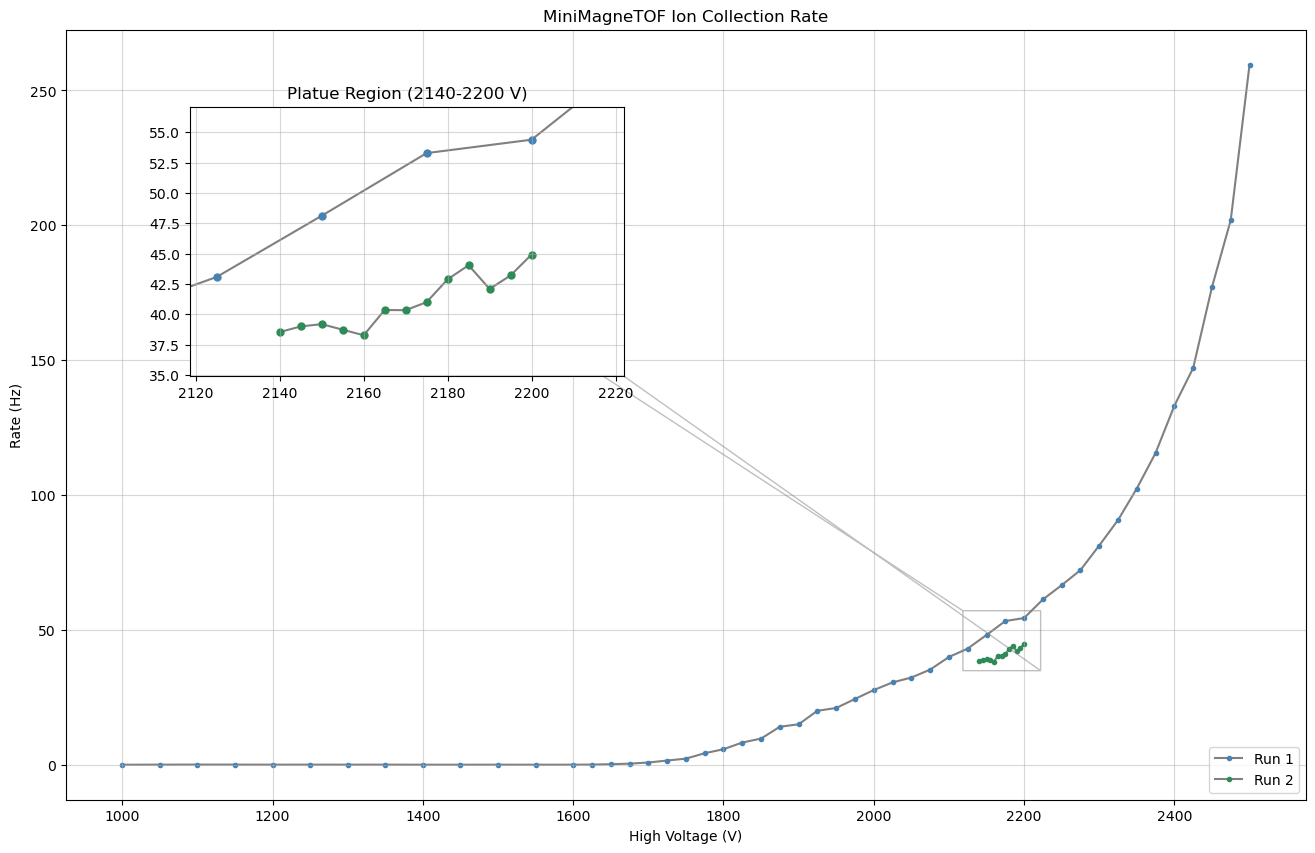

In [4]:
fig, ax = plt.subplots(figsize=(16, 10))

run1 = df[df["run"] == 1]
run2 = df[df["run"] == 2]

# Run 1 Points:
ax.plot(run1["hv_volts"], run1["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='steelblue', markeredgecolor='steelblue', label="Run 1")
# Run 2 Points:
ax.plot(run2["hv_volts"], run2["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='seagreen', markeredgecolor='seagreen', label="Run 2")
ax.set_title("MiniMagneTOF Ion Collection Rate")
ax.set_xlabel("High Voltage (V)")
ax.set_ylabel("Rate (Hz)")
ax.grid(alpha=0.5)
ax.legend(loc="lower right")

ax_inset = ax.inset_axes([0.1, 0.55, 0.35, 0.35])
ax_inset.plot(run1["hv_volts"], run1["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='steelblue', markeredgecolor='steelblue')
ax_inset.plot(run2["hv_volts"], run2["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='seagreen', markeredgecolor='seagreen')
ax_inset.set_xlim(2140 * 0.99, 2200 * 1.01)

mask = (df["hv_volts"] >= 2140) & (df["hv_volts"] <= 2200)
y_in_range = run1.loc[mask, "rate_hz"] 
ax_inset.set_ylim(y_in_range.min() * 0.725, y_in_range.max() * 1.05)
ax_inset.grid(alpha=0.5)
ax_inset.set_title("Platue Region (2140-2200 V)")

ax.indicate_inset_zoom(ax_inset, edgecolor="gray")

plt.show()